In [1]:
import os
import shutil

# 1. Set environment variables BEFORE any imports that use SQLite/diskcache
os.environ['SQLITE_TMPDIR'] = '/tmp'
os.environ['TMPDIR'] = '/tmp'
os.environ['XDG_CACHE_HOME'] = '/tmp/cache_' + os.environ.get('USER', 'user')

# 2. Create the local cache directory
local_cache = os.environ['XDG_CACHE_HOME']
os.makedirs(local_cache, exist_ok=True)

# 3. Clean up old problematic cache locations
paths_to_remove = [
    os.path.expanduser("~/.cache/genomepy"),
    os.path.expanduser("~/.cache/diskcache"),
    os.path.expanduser("~/.local/share/genomepy"),
]

for path in paths_to_remove:
    if os.path.exists(path):
        try:
            shutil.rmtree(path)
            print(f"Removed: {path}")
        except Exception as e:
            print(f"Failed to remove {path}: {e}")

# 4. Disable genomepy caching entirely (optional but often helps)
os.environ['GENOMEPY_CACHE'] = 'false'

In [2]:
import celloracle as co

/ocean/projects/cis240075p/asachan/.conda/envs/celloracle_env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


In [3]:
import numpy as np, pandas as pd, scanpy as sc, matplotlib.pyplot as plt, os
from scipy.stats import hypergeom
import glob, pickle
from functools import reduce
from tqdm import tqdm
import itertools, math, random
import networkx as nx

# visualization settings required to see plots in jupyter notebook
%config InlineBackend.figure_format = 'retina'
%matplotlib inline
plt.rcParams['figure.figsize'] = [6, 4.5]
plt.rcParams["savefig.dpi"] = 300

wd = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/grn_CO/male_type2'
feature_folder = '/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/slide_outs/optimize_slide/male_0.2_spec/0.1_0.1_out'
out_path = os.path.join(wd, 'lf_enrich')
os.makedirs(f"{out_path}/figures", exist_ok=True)
os.makedirs(f"{out_path}/out_files", exist_ok=True)
os.makedirs(f"{out_path}/out_files/SLIDE_LF_enrichment", exist_ok=True)
sc.settings.figdir = f"{out_path}/figures"
random.seed(42)

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [4]:
oracle = co.load_hdf5(f"{wd}/out_files/male_type2_fitted.celloracle.oracle")
#stream_xdr = pd.read_csv("/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/stream_outs/male_traj_fast2b.h5ad", index_col=0) #x,y,leiden,S2_pseudotime

In [5]:
oracle.adata.obsm['X_umap']

array([[7.970654 , 9.350728 ],
       [8.903457 , 3.658229 ],
       [8.49856  , 6.0654645],
       ...,
       [8.211392 , 7.3498254],
       [6.4385924, 9.829204 ],
       [7.617322 , 6.8340836]])

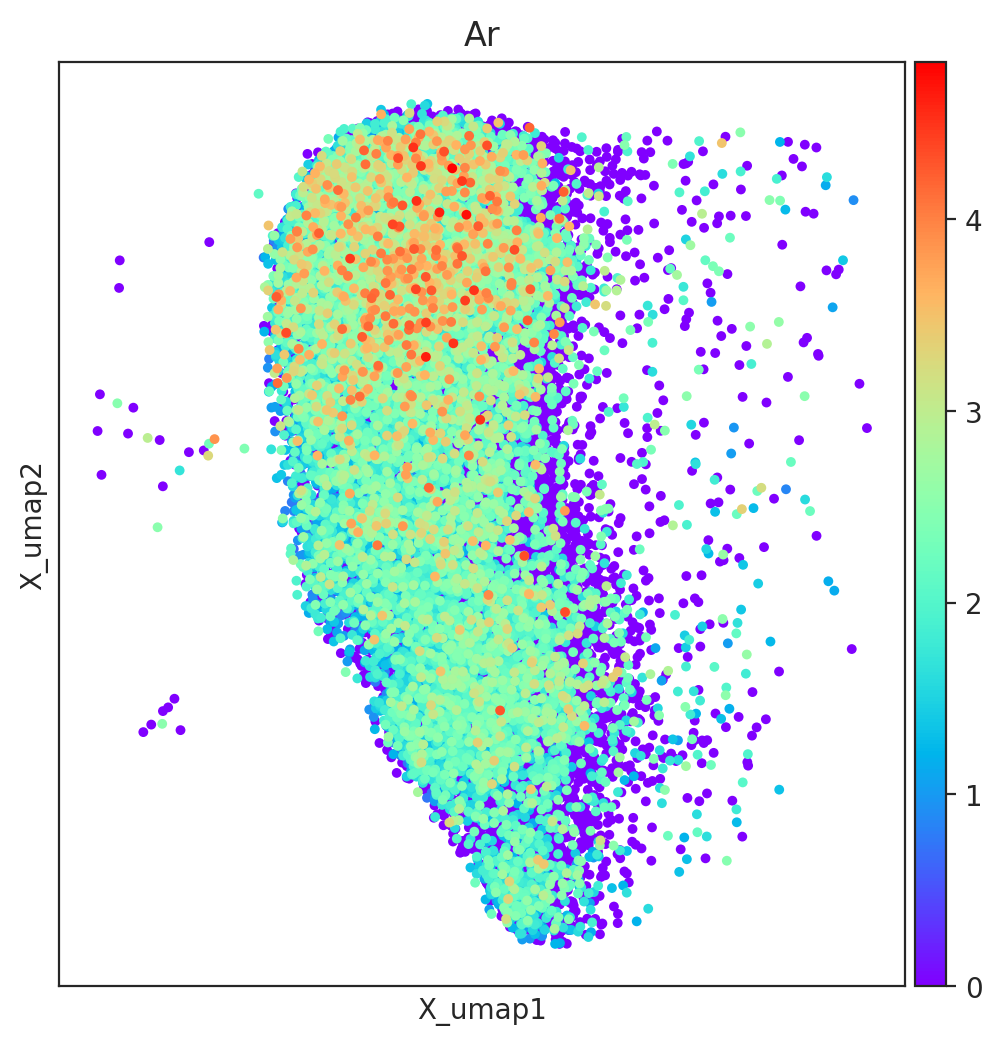

In [6]:
# Visualize pseudotime
fig, ax = plt.subplots(figsize=[6,6])
sc.pl.embedding(adata=oracle.adata, basis= 'X_umap', ax=ax, cmap="rainbow", color=["Ar"],s=50)

In [7]:
goi = 'Ar'
print(f'Simulating perturbation for {goi}', flush=True)
oracle.simulate_shift(perturb_condition={goi: 0.0},n_propagation=2) # If kernal crashes increase the memory limit of jupyter notebook
print(f'Estimating transition probability for {goi}', flush=True)
oracle.estimate_transition_prob(n_neighbors=750, knn_random=True, sampled_fraction=1) # Get transition probability
print(f'Calculating embedding for {goi}', flush=True)
oracle.calculate_embedding_shift(sigma_corr=0.05) # Calculate embedding

Simulating perturbation for Ar


Estimating transition probability for Ar
Calculating embedding for Ar


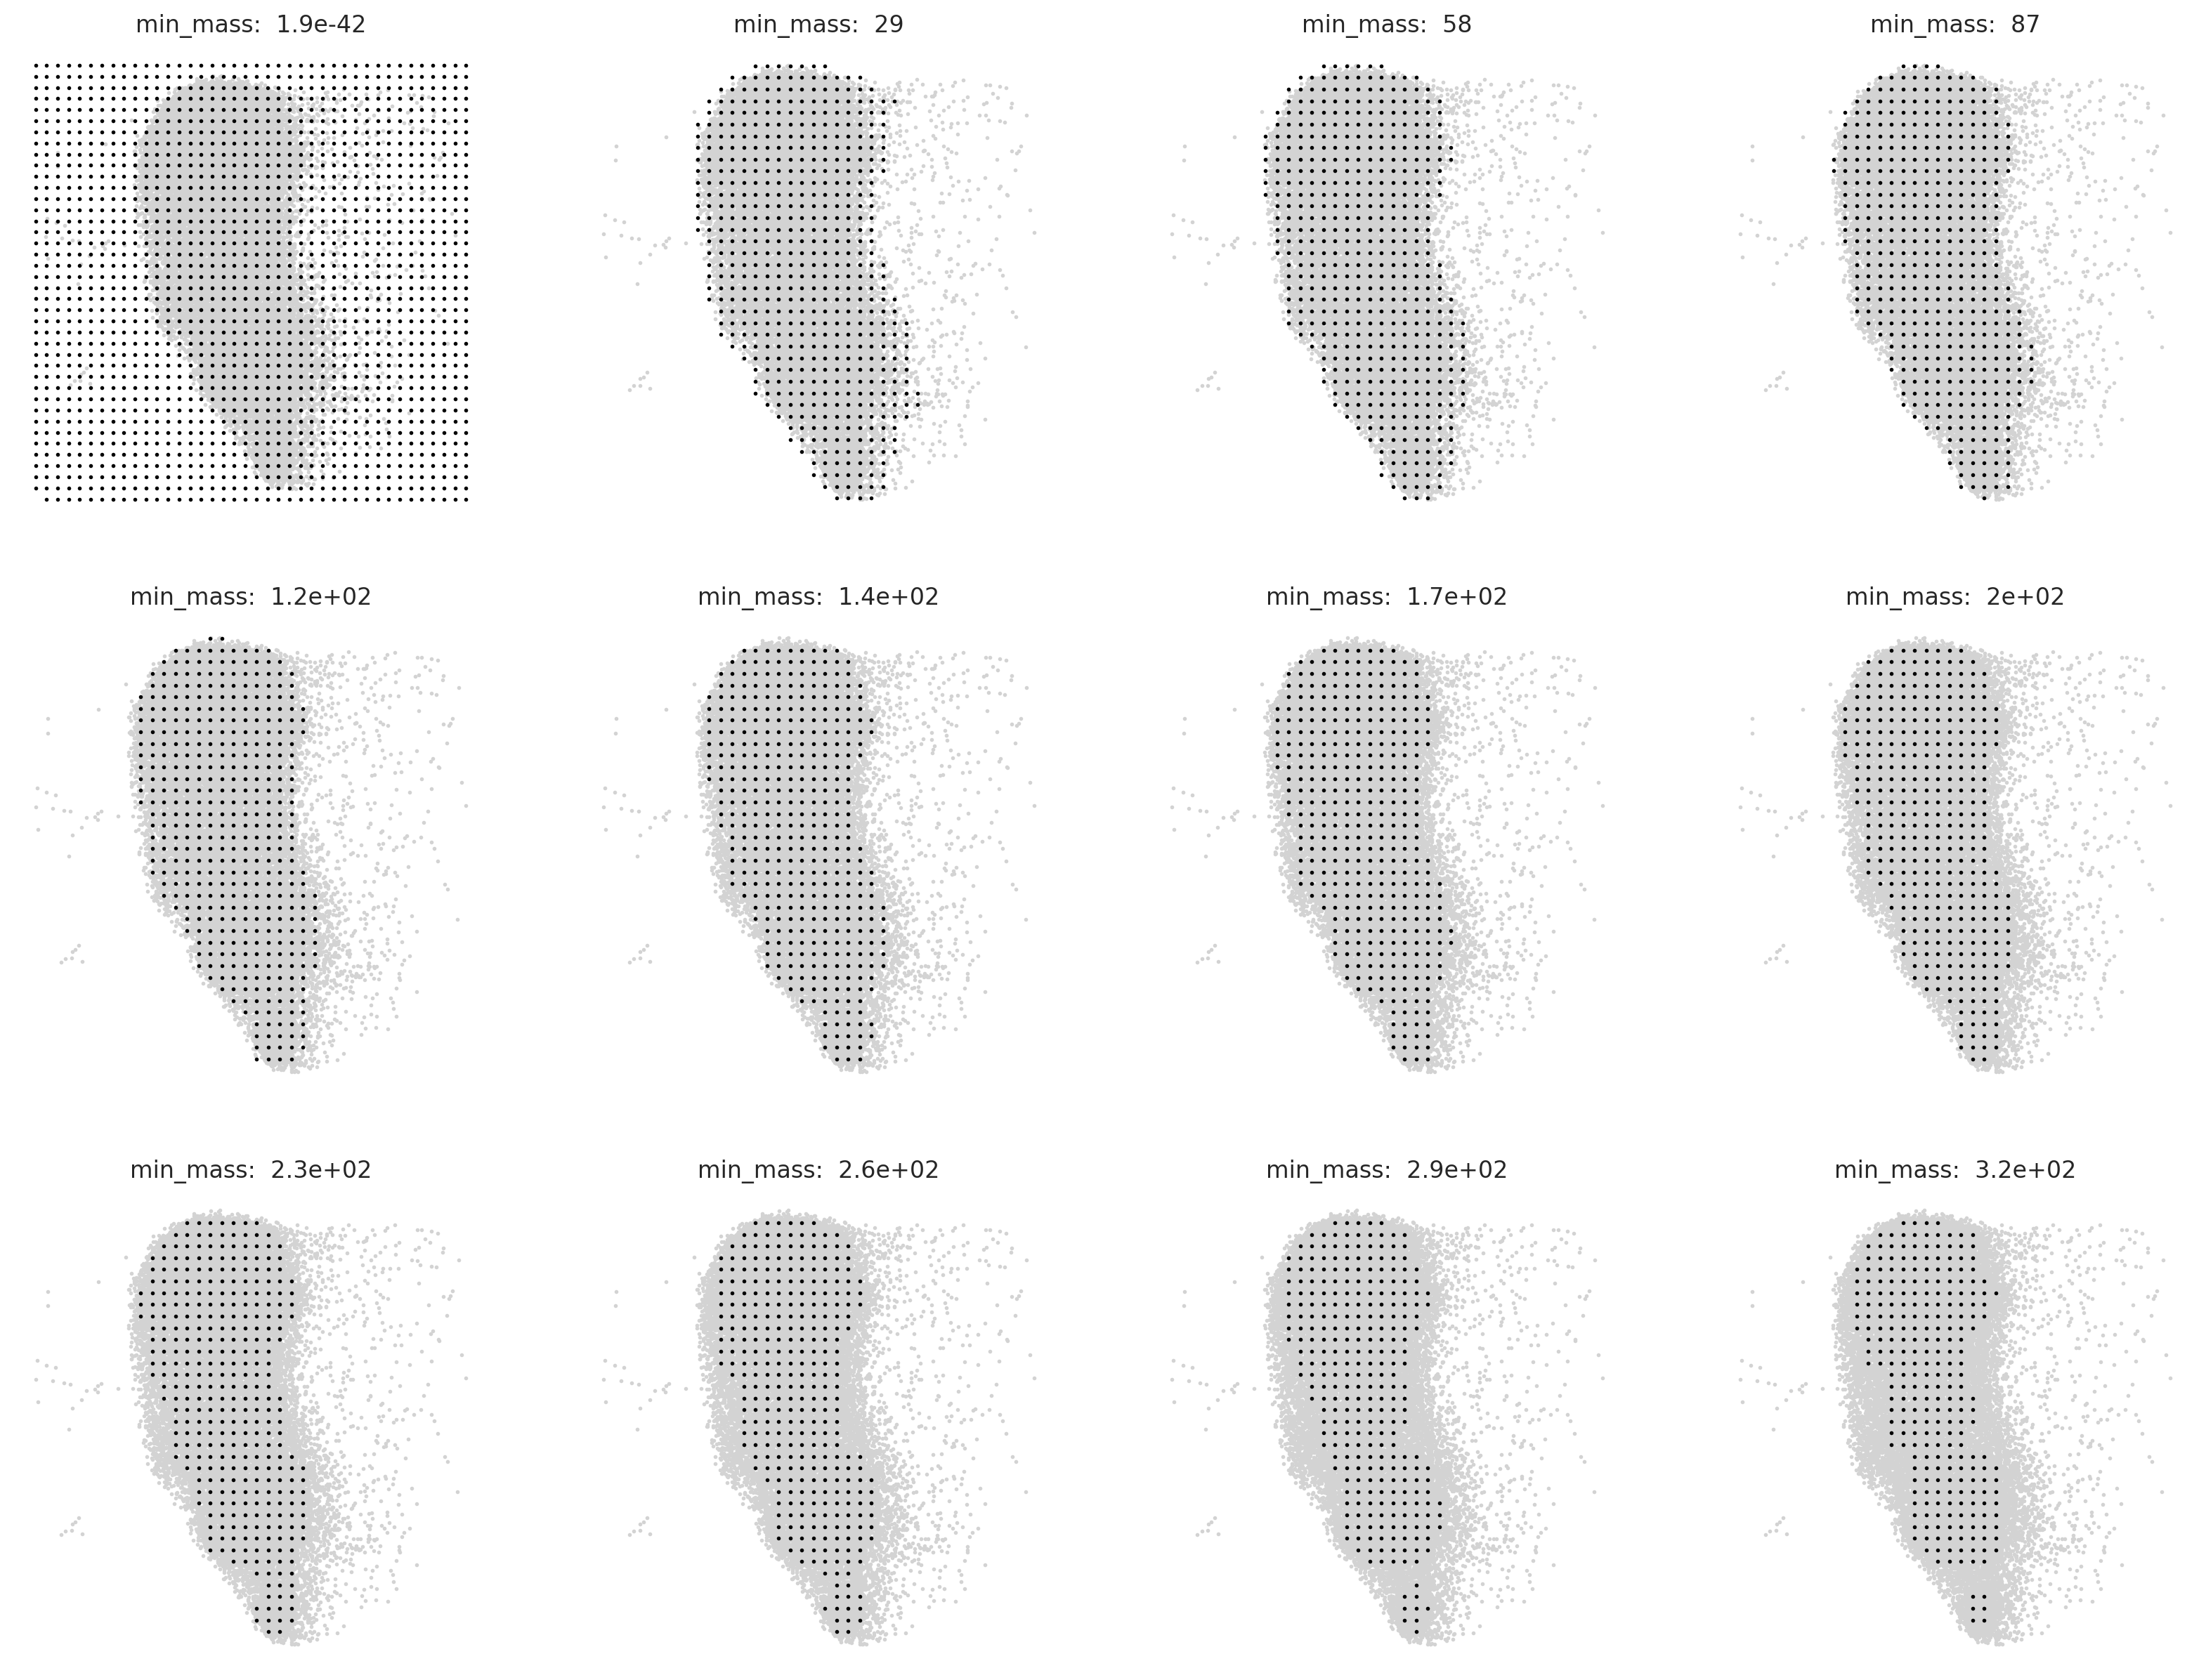

In [8]:
n_grid=40
oracle.calculate_p_mass(smooth=0.8, n_grid=n_grid, n_neighbors=750)
# Search for best min_mass.
oracle.suggest_mass_thresholds(n_suggestion=12)

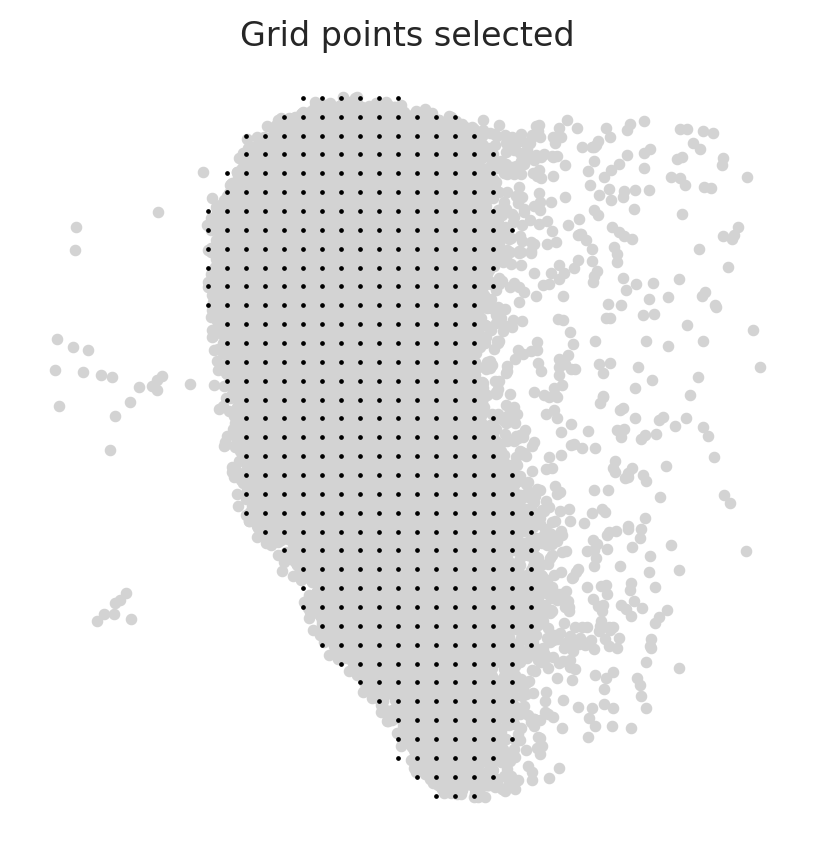

In [9]:
min_mass=60
oracle.calculate_mass_filter(min_mass=min_mass, plot=True)

<AxesSubplot: title={'center': 'condition'}, xlabel='UMAP1', ylabel='UMAP2'>

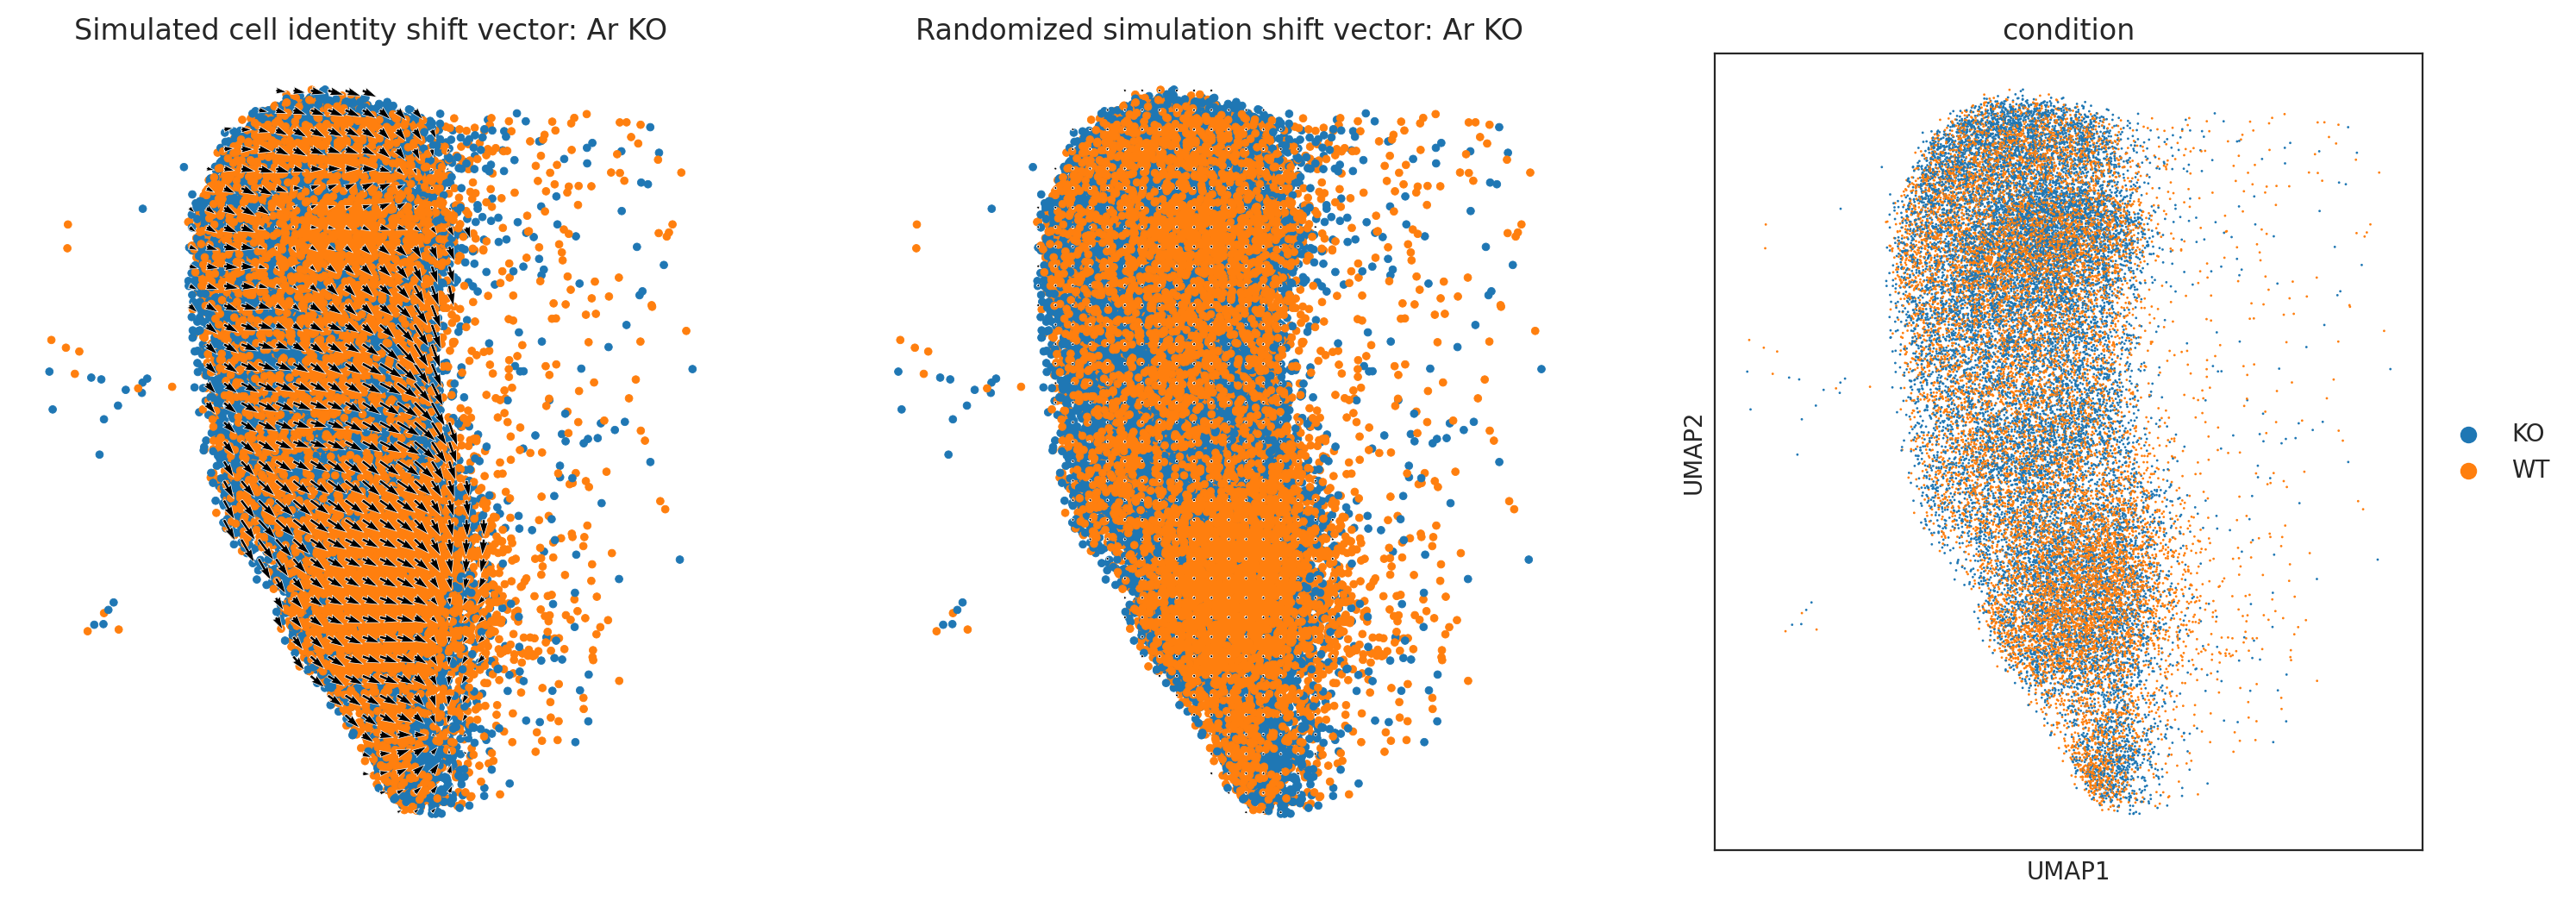

In [10]:
scale_simulation=15

fig, ax = plt.subplots(1, 3,  figsize=[18, 6])
oracle.plot_cluster_whole(ax=ax[0], s=10)
ax[0].set_title(f"Simulated cell identity shift vector: {goi} KO")
oracle.plot_simulation_flow_on_grid(scale=scale_simulation, ax=ax[0], show_background=False)
oracle.plot_cluster_whole(ax=ax[1], s=10)
ax[1].set_title(f"Randomized simulation shift vector: {goi} KO")
oracle.plot_simulation_flow_random_on_grid(scale=scale_simulation, ax=ax[1], show_background=False)
ax[2].set_title(f"Clustered cell identity")  
sc.pl.umap(oracle.adata, color=['condition'], ax=ax[2], show=False)

In [18]:
from numpy import shape
display(shape(oracle.flow))
display(len(oracle.flow_grid))

(1600, 2)

1600